# Glicko-2 implementation

Implements the Glicko-2 algorithm directly from:
Glickman, M.E. (2022) "Example of the Glicko-2 System"
http://www.glicko.net/glicko/glicko2.pdf
Every function traces to a specific equation in the paper. Validated against
Glickman's worked example (Table 1) before running on UFC data.

## Section 1: Setup

Mount Drive and import the libraries used throughout.

In [ ]:
# BLOCK 1: library imports and data location

import pandas as pd
import numpy as np
from pathlib import Path

# data location (portable across Drive and a local repo checkout)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except (ImportError, ModuleNotFoundError):
    pass  # not in Colab

DRIVE_DIR = Path('/content/drive/MyDrive/Masters in Artificial Intelligence Applied to Sport/'
                 'Masters Final Project/Pugnator mapper valorem/EDA/Code Outputs')
OUTPUT_DIR = DRIVE_DIR if DRIVE_DIR.exists() else Path('./data')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Using data directory: {OUTPUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Section 2: Glicko-2 implementation

Implement the Glicko-2 system from Glickman (2022): the system constants, scale conversion, the g and E functions, the volatility update, and the full period update, then validate the implementation against the paper's worked example.

In [ ]:
# BLOCK 2: System constants (Glickman 2022, Section 2)

# MU: default rating on the Glicko-2 internal scale (0, not 1500)
# PHI: default RD on the internal scale (350/173.7178 ≈ 2.0147)
# SIGMA: default volatility (Glickman suggests 0.06 as a starting point)
# TAU: system constant constraining volatility change. Smaller = more
#      conservative volatility updates. Glickman suggests 0.3-1.2
# EPSILON: convergence tolerance for the volatility iteration
# SCALE: the conversion factor between Glicko-2 and Glicko-1 scales

SCALE = 173.7178
MU = 0.0
PHI = 350 / SCALE  # ≈ 2.0147
SIGMA = 0.06
TAU = 0.5
EPSILON = 0.000001
SIGMA_INACTIVE_FLOOR = 0.18  # was 0.25; 0.25 over-penalised routine gaps

print(f"Default rating (display): 1500")
print(f"Default RD (display): 350")
print(f"Default volatility: {SIGMA}")
print(f"Tau: {TAU}")
print(f"Scale factor: {SCALE}")
print(f"SIGMA Inactive Floor: {SIGMA_INACTIVE_FLOOR}")

Default rating (display): 1500
Default RD (display): 350
Default volatility: 0.06
Tau: 0.5
Scale factor: 173.7178
SIGMA Inactive Floor: 0.18


In [ ]:
# BLOCK 3: Scale conversion (Glickman 2022, Step 1 and Step 8)

# Glicko-2 uses an internal scale centred at 0.
# Display ratings are on the traditional scale centred at 1500.
# These two functions convert between them.

# Display to Glicko-2
def scale_down(rating, rd):
    mu = (rating - 1500) / SCALE
    phi = rd / SCALE
    return mu, phi

# Glicko-2 to Display
def scale_up(mu, phi):
    rating = mu * SCALE + 1500
    rd = phi * SCALE
    return rating, rd

# Test
mu, phi = scale_down(1500, 350)
print(f"scale_down(1500, 350) > mu={mu:.4f}, phi={phi:.4f}")
rating, rd = scale_up(mu, phi)
print(f"scale_up back > rating={rating:.1f}, rd={rd:.1f}")
assert abs(rating - 1500) < 0.01 and abs(rd - 350) < 0.01, "Test Failed"
print("Test OK")

scale_down(1500, 350) > mu=0.0000, phi=2.0148
scale_up back > rating=1500.0, rd=350.0
Test OK


In [ ]:
# BLOCK 4: g(phi) and E(mu, mu_j, phi_j)

# Glickman 2022, Step 2
# g(phi) adjusts the impact of a result against an opponent based on their RD.
# E is the expected outcome
# Glicko g function > reduces weight for high uncertainty

def g(phi):
    return 1 / math.sqrt(1 + 3 * phi**2 / math.pi**2)

# Expected outcome for fighter (mu) vs opponent (mu_j, phi_j)
def expected_score(mu, mu_j, phi_j):
    return 1 / (1 + math.exp(-g(phi_j) * (mu - mu_j)))

# Test a 1700-rated fighter vs a 1500-rated opponent with default RD
mu_a, phi_a = scale_down(1700, 80)
mu_b, phi_b = scale_down(1500, 150)

print(f"Fighter A: rating 1700, RD 80 > mu={mu_a:.4f}, phi={phi_a:.4f}")
print(f"Fighter B: rating 1500, RD 150 > mu={mu_b:.4f}, phi={phi_b:.4f}")
print(f"g(phi_b) = {g(phi_b):.4f}")
print(f"E(A beats B) = {expected_score(mu_a, mu_b, phi_b):.4f}")
print()
# Check: A is rated higher, so E should be > 0.5
# Higher opponent RD means g is smaller
print("Sanity checks:")
print(f"  A rated higher than B, so E > 0.5: {expected_score(mu_a, mu_b, phi_b) > 0.5}")
print(f"  Equal ratings -> E = 0.5: {expected_score(mu_a, mu_a, phi_b):.4f}")

Fighter A: rating 1700, RD 80 > mu=1.1513, phi=0.4605
Fighter B: rating 1500, RD 150 > mu=0.0000, phi=0.8635
g(phi_b) = 0.9029
E(A beats B) = 0.7388

Sanity checks:
  A rated higher than B, so E > 0.5: True
  Equal ratings -> E = 0.5: 0.5000


In [ ]:
# BLOCK 5: Volatility update (Glickman 2022, Step 5)

# This finds the new volatility (sigma').
#
# Glickman uses the Illinois algorithm (a bracketed root-finding method).

# Inputs:
#   phi: current RD (internal scale)
#   sigma: current volatility
#   v: estimated variance from the outcomes (computed in Step 3)
#   delta: estimated improvement from the outcomes (computed in Step 4)

# Output:
#   sigma_new: the updated volatility

# The TAU controls how much volatility can change per period.

def update_volatility(phi, sigma, v, delta):

    # The function f(x) whose root we need to find
    a = math.log(sigma**2)

    def f(x):
        ex = math.exp(x)
        num1 = ex * (delta**2 - phi**2 - v - ex)
        den1 = 2 * (phi**2 + v + ex)**2
        return num1 / den1 - (x - a) / TAU**2

    # Set the initial bracket [A, B]
    # A is always log(sigma^2)
    A = a

    # B depends on whether delta^2 > phi^2 + v
    if delta**2 > phi**2 + v:
        B = math.log(delta**2 - phi**2 - v)
    else:
        # Find B by stepping down from A until f(B) < 0
        k = 1
        while f(a - k * TAU) < 0:
          k += 1
        B = a - k * TAU

    # Iterative search (Illinois algorithm)
    fA = f(A)
    fB = f(B)

    while abs(B - A) > EPSILON:
        # find the midpoint C
        C = A + (A - B) * fA / (fB - fA)
        fC = f(C)

        if fC * fB <= 0:
            # Root is between C and B
            A = B
            fA = fB
        else:
            # Illinois adjustment (halve fA to force convergence)
            fA = fA / 2

        B = C
        fB = fC

    # The new volatility is exp(A/2)
    sigma_new = math.exp(A / 2)
    return sigma_new

# Test with a simple case
mu_test, phi_test = scale_down(1500, 200)
v_test = 1.0  # placeholder variance
delta_test = 0.5  # moderate improvement

sigma_new = update_volatility(phi_test, SIGMA, v_test, delta_test)
print(f"Volatility update test:")
print(f"  Input sigma: {SIGMA}")
print(f"  Output sigma: {sigma_new:.6f}")
print(f"  Changed by: {abs(sigma_new - SIGMA):.6f}")
print(f"  Converged: {abs(sigma_new - SIGMA) < 0.1}")

Volatility update test:
  Input sigma: 0.06
  Output sigma: 0.059995
  Changed by: 0.000005
  Converged: True


In [ ]:
# BLOCK 6: Find the avg for inter fight gap distribution

# The median gap should be used as the base period length for RD decay.

# Load events table
BASE_URL = "https://raw.githubusercontent.com/th1555/ufc-fighter-value-mapper/refs/heads/main/raw_data/"
df_events = pd.read_csv(BASE_URL + 'ufc_event_details.csv')
for col in df_events.select_dtypes(include='object').columns:
    df_events[col] = df_events[col].str.strip()
df_events['DATE_PARSED'] = pd.to_datetime(df_events['DATE'], errors='coerce')

df_results = pd.read_csv(BASE_URL + 'ufc_fight_results.csv')
for col in df_results.select_dtypes(include='object').columns:
    df_results[col] = df_results[col].str.strip()

# Attach dates
df_results = df_results.merge(df_events[['EVENT', 'DATE_PARSED']], on='EVENT', how='left')

# Bouts into fighter rows with dates
rows = []
for _, fight in df_results.iterrows():
    if pd.isna(fight['BOUT']) or ' vs. ' not in str(fight['BOUT']):
        continue
    parts = str(fight['BOUT']).split(' vs. ')
    if len(parts) != 2:
        continue
    date = fight['DATE_PARSED']
    rows.append({'FIGHTER': parts[0].strip(), 'DATE': date})
    rows.append({'FIGHTER': parts[1].strip(), 'DATE': date})

df_timeline = pd.DataFrame(rows).dropna(subset=['DATE']).sort_values(['FIGHTER', 'DATE'])

# Calculate gaps between consecutive fights per fighter
df_timeline['PREV_DATE'] = df_timeline.groupby('FIGHTER')['DATE'].shift(1)
df_timeline['GAP_DAYS'] = (df_timeline['DATE'] - df_timeline['PREV_DATE']).dt.days
gaps = df_timeline['GAP_DAYS'].dropna()

print("Inter-fight gap distribution (days):")
print(f"  Mean:   {gaps.mean():.0f}")
print(f"  Median: {gaps.median():.0f}")
print(f"  25th:   {gaps.quantile(0.25):.0f}")
print(f"  75th:   {gaps.quantile(0.75):.0f}")
print(f"  90th:   {gaps.quantile(0.90):.0f}")
print()

# Convert to months
print("In months (approximate):")
print(f"  Mean:   {gaps.mean()/30:.1f}")
print(f"  Median: {gaps.median()/30:.1f}")
print(f"  25th:   {gaps.quantile(0.25)/30:.1f}")
print(f"  75th:   {gaps.quantile(0.75)/30:.1f}")

Inter-fight gap distribution (days):
  Mean:   219
  Median: 168
  25th:   126
  75th:   245
  90th:   371

In months (approximate):
  Mean:   7.3
  Median: 5.6
  25th:   4.2
  75th:   8.2


In [ ]:
# BLOCK 7: Full period rating update (Glickman 2022, Steps 2-8)

# Combibes g(), expected_score(), and update_volatility() into a
# complete update process for one fighter after one rating period.

# One rating period = one fight.
# The period LENGTH for inactivity decay is 180 days (see calc from Block 6 - median 168 days):
# A fighter inactive for 360 days has had two periods of RD growth. The decay is
# applied as a pre step in run_glicko() based on elapsed days since
# the fighter's last fight

# Inputs:
#   mu, phi, sigma: fighter's current state (internal scale)
#   opponents: list of (mu_j, phi_j) tuples for each opponent faced
#   outcomes: list of scores (1.0 = win, 0.0 = loss, 0.5 = draw)

# Returns:
#   (mu_new, phi_new, sigma_new) on the internal scale

RATING_PERIOD_DAYS = 180  # calibrated from median inter-fight gap (168 days)

def update_rating(mu, phi, sigma, opponents, outcomes):

    # In the UFC_Value_Mapper implementation this branch will not be used
    # directly; (see note on handing inactivy decay above)
    if not opponents:
        phi_new = math.sqrt(phi**2 + sigma**2)
        return mu, phi_new, sigma

    # Compute the estimated variance (v) and compute the estimated improvement
    # (delta)
    # Both accumulate over all opponents in the period
    v_sum = 0.0
    delta_sum = 0.0

    for (mu_j, phi_j), outcome in zip(opponents, outcomes):
        g_j = g(phi_j)
        E_j = expected_score(mu, mu_j, phi_j)

        # Variance component
        v_sum += g_j**2 * E_j * (1 - E_j)

        # Improvement component (actual vs expected, weighted by g)
        delta_sum += g_j * (outcome - E_j)

    v = 1.0 / v_sum
    delta = v * delta_sum

    # Update volatility
    sigma_new = update_volatility(phi, sigma, v, delta)

    # RD increases by volatility (confidence decays)
    phi_star = math.sqrt(phi**2 + sigma_new**2)
    # RD decreases from the information gained
    phi_new = 1.0 / math.sqrt(1.0 / phi_star**2 + 1.0 / v)

    # Update rating
    mu_new = mu + phi_new**2 * delta_sum

    return mu_new, phi_new, sigma_new

print("update_rating() defined.")

update_rating() defined.


In [ ]:
# BLOCK 8: Validate against Glickman (2022) example:

# Player rated 1500 (RD 200, sigma 0.06) plays three opponents in one rating
# period.

# Glickman's expected outputs (from the paper):
#   New rating:     1464.06
#   New RD:         151.52
#   New volatility: 0.05999 (approximately)
# Match = Success

print("GLICKO-2 EXAMPLE VALIDATION")
print()

# Player's initial state
player_rating, player_rd = 1500, 200
player_sigma = 0.06

# Convert to internal scale
mu, phi = scale_down(player_rating, player_rd)
print(f"Player: rating={player_rating}, RD={player_rd}, sigma={player_sigma}")
print(f"  Internal: mu={mu:.4f}, phi={phi:.4f}")
print()

# Three opponents
opp_data = [
    (1400, 30,  1.0),  # opponent 1: rated 1400, RD 30, player WINS
    (1550, 100, 0.0),  # opponent 2: rated 1550, RD 100, player LOSES
    (1700, 300, 0.0),  # opponent 3: rated 1700, RD 300, player LOSES
]

opponents = []
outcomes = []
for rating_j, rd_j, outcome in opp_data:
    mu_j, phi_j = scale_down(rating_j, rd_j)
    opponents.append((mu_j, phi_j))
    outcomes.append(outcome)
    E = expected_score(mu, mu_j, phi_j)
    print(f"  Opponent {rating_j} (RD {rd_j}): E={E:.4f}, outcome={outcome}")

print()

# Run the update
mu_new, phi_new, sigma_new = update_rating(mu, phi, player_sigma, opponents, outcomes)

# Convert to display scale
rating_new, rd_new = scale_up(mu_new, phi_new)

print("Results:")
print(f"  New rating:     {rating_new:.2f}   (Glickman: 1464.06)")
print(f"  New RD:         {rd_new:.2f}   (Glickman: 151.52)")
print(f"  New volatility: {sigma_new:.5f}  (Glickman: ~0.05999)")
print()

# Check tolerance
rating_ok = abs(rating_new - 1464.06) < 1.0
rd_ok = abs(rd_new - 151.52) < 1.0
sigma_ok = abs(sigma_new - 0.05999) < 0.001

print("Validation:")
print(f"  Rating within 1.0 of expected:  {rating_ok}")
print(f"  RD within 1.0 of expected:      {rd_ok}")
print(f"  Volatility within 0.001:        {sigma_ok}")

if rating_ok and rd_ok and sigma_ok:
    print()
    print("PASSED. Matches Glicko-2 Example")
else:
    print()
    print("FAILED. Differs from Glicko-2 Example")

GLICKO-2 EXAMPLE VALIDATION

Player: rating=1500, RD=200, sigma=0.06
  Internal: mu=0.0000, phi=1.1513

  Opponent 1400 (RD 30): E=0.6395, outcome=1.0
  Opponent 1550 (RD 100): E=0.4318, outcome=0.0
  Opponent 1700 (RD 300): E=0.3028, outcome=0.0

Results:
  New rating:     1464.05   (Glickman: 1464.06)
  New RD:         151.52   (Glickman: 151.52)
  New volatility: 0.06000  (Glickman: ~0.05999)

Validation:
  Rating within 1.0 of expected:  True
  RD within 1.0 of expected:      True
  Volatility within 0.001:        True

PASSED. Matches Glicko-2 Example


## Section 3: Rating computation and reliability tiers

Apply inactivity decay, run the rating engine across the full fighter set, and classify each fighter's rating deviation into reliability tiers. The filtered and unfiltered rankings are compared to justify the reliability threshold.

In [ ]:
# BLOCK 9: Inactivity decay

# The longer they have are inactive, a fighter's RD grows to show less certainty
# about their rating
# The growth rate is controlled by volatility (sigma) and scaled by the number
# of rating periods passed.

# Inputs: phi, sigma (current state), elapsed_days (days since last fight)
# Returns: phi_decayed

def apply_inactivity_decay(phi, sigma, elapsed_days):
    if elapsed_days is None or elapsed_days <= 0:
        return phi  # first fight or same-day; no decay

    n_periods = elapsed_days / RATING_PERIOD_DAYS

    # MMA layoff decay is faster than chess, which is set by Default;
    # Pure Glicko-2 mixes rating uncertainty with skill drift during inactivity
    # which understates layoff erosion in MMA.
    sigma_inactive = max(sigma, SIGMA_INACTIVE_FLOOR)
    phi_decayed = math.sqrt(phi**2 + n_periods * sigma_inactive**2)

    # Cap RD at the initial value (350 display = ~2.0147 internal) so a
    # fighter inactive for years doesn't have crazy RD
    phi_decayed = min(phi_decayed, PHI)
    return phi_decayed

# Test
print(f"Default phi (RD 350): {PHI:.4f}")
print()
print("Decay examples (starting from phi corresponding to RD 80):")
phi_test = 80 / SCALE
print(f"  No time passed:    phi = {apply_inactivity_decay(phi_test, 0.06, 0):.4f}")
print(f"  90 days:           phi = {apply_inactivity_decay(phi_test, 0.06, 90):.4f}")
print(f"  180 days (circa 1 period):  phi = {apply_inactivity_decay(phi_test, 0.06, 180):.4f}")
print(f"  365 days (circa 2 period): phi = {apply_inactivity_decay(phi_test, 0.06, 365):.4f}")
print(f"  1000 days (circa 5.5):  phi = {apply_inactivity_decay(phi_test, 0.06, 1000):.4f}")
print()
print("In display scale (RD):")
for days in [0, 90, 180, 365, 1000]:
    phi_d = apply_inactivity_decay(phi_test, 0.06, days)
    print(f"  {days:>4d} days: RD = {phi_d * SCALE:.1f}")

Default phi (RD 350): 2.0148

Decay examples (starting from phi corresponding to RD 80):
  No time passed:    phi = 0.4605
  90 days:           phi = 0.4778
  180 days (circa 1 period):  phi = 0.4944
  365 days (circa 2 period): phi = 0.5270
  1000 days (circa 5.5):  phi = 0.6262

In display scale (RD):
     0 days: RD = 80.0
    90 days: RD = 83.0
   180 days: RD = 85.9
   365 days: RD = 91.6
  1000 days: RD = 108.8


In [ ]:
# BLOCK 10: Run Glicko-2 on full fighter set

# Process fights chronologically. For each bout:
#   Apply inactivity decay to both fighters' RD
#   Rating updates from the PRE-fight state of both fighters
#   (capture both states first!; doing them sequentially = post fight A against pre fight B)
#   Add both updates to fighter state
#   Log the post fight state

# Load the modelable bouts
df_fights = pd.read_parquet(OUTPUT_DIR / 'fights_per_fighter.parquet')
print(f"Loaded {len(df_fights):,} fighter rows ({len(df_fights)//2:,} bouts)")

# Sort by date to process chronologically (Glicko-2 needs ordered input).
df_fights = df_fights.sort_values(['DATE_PARSED', 'FIGHT_ID']).reset_index(drop=True)
print(f"Date range: {df_fights['DATE_PARSED'].min()} to {df_fights['DATE_PARSED'].max()}")

# Group by FIGHT_ID, one row per fighter
bouts = df_fights.groupby('FIGHT_ID', sort=False)

print(f"Bouts to process: {len(bouts):,}")
print("Ready for the main loop.")

Loaded 17,358 fighter rows (8,679 bouts)
Date range: 1994-03-11 00:00:00 to 2026-07-11 00:00:00
Bouts to process: 8,679
Ready for the main loop.


In [ ]:
# BLOCK 11: Main Glicko-2 loop

# Fighter state: name > {'mu': ..., 'phi': ..., 'sigma': ..., 'last_date': ...}
fighter_state = {}

# Get current state
def get_or_init(name):
    if name not in fighter_state:
        fighter_state[name] = {
            'mu': MU, 'phi': PHI, 'sigma': SIGMA, 'last_date': None
        }
    return fighter_state[name]

# History log
history = []

# Process each fight
n_processed = 0
n_skipped_no_date = 0

for fight_id, bout_rows in bouts:
    # bout_rows = df with 2 rows
    if len(bout_rows) != 2:
        continue  # guard

    row_a, row_b = bout_rows.iloc[0], bout_rows.iloc[1]
    fight_date = row_a['DATE_PARSED']

    if pd.isna(fight_date):
        n_skipped_no_date += 1
        continue

    name_a, name_b = row_a['FIGHTER'], row_b['FIGHTER']
    score_a, score_b = row_a['SCORE'], row_b['SCORE']

    # Get pre fight state for both fighters
    state_a = get_or_init(name_a)
    state_b = get_or_init(name_b)

    # Apply inactivity decay to RD
    if state_a['last_date'] is not None:
        elapsed_a = (fight_date - state_a['last_date']).days
        state_a['phi'] = apply_inactivity_decay(state_a['phi'], state_a['sigma'], elapsed_a)
    if state_b['last_date'] is not None:
        elapsed_b = (fight_date - state_b['last_date']).days
        state_b['phi'] = apply_inactivity_decay(state_b['phi'], state_b['sigma'], elapsed_b)

    # Record pre fight state (Do this before either update!!)
    pre_a = (state_a['mu'], state_a['phi'], state_a['sigma'])
    pre_b = (state_b['mu'], state_b['phi'], state_b['sigma'])

    # Updates from the pre fight record
    mu_a_new, phi_a_new, sigma_a_new = update_rating(
        pre_a[0], pre_a[1], pre_a[2],
        opponents=[(pre_b[0], pre_b[1])],
        outcomes=[score_a]
    )
    mu_b_new, phi_b_new, sigma_b_new = update_rating(
        pre_b[0], pre_b[1], pre_b[2],
        opponents=[(pre_a[0], pre_a[1])],
        outcomes=[score_b]
    )

    # Add updates to state
    state_a['mu'], state_a['phi'], state_a['sigma'] = mu_a_new, phi_a_new, sigma_a_new
    state_a['last_date'] = fight_date
    state_b['mu'], state_b['phi'], state_b['sigma'] = mu_b_new, phi_b_new, sigma_b_new
    state_b['last_date'] = fight_date

    # Log history (in display scale)
    rating_a_pre, rd_a_pre = scale_up(pre_a[0], pre_a[1])
    rating_a_post, rd_a_post = scale_up(mu_a_new, phi_a_new)
    rating_b_pre, rd_b_pre = scale_up(pre_b[0], pre_b[1])
    rating_b_post, rd_b_post = scale_up(mu_b_new, phi_b_new)

    history.append({
        'FIGHT_ID': fight_id, 'DATE': fight_date, 'FIGHTER': name_a,
        'OPPONENT': name_b, 'SCORE': score_a,
        'RATING_PRE': rating_a_pre, 'RD_PRE': rd_a_pre,
        'RATING_POST': rating_a_post, 'RD_POST': rd_a_post,
        'SIGMA_POST': sigma_a_new,
    })
    history.append({
        'FIGHT_ID': fight_id, 'DATE': fight_date, 'FIGHTER': name_b,
        'OPPONENT': name_a, 'SCORE': score_b,
        'RATING_PRE': rating_b_pre, 'RD_PRE': rd_b_pre,
        'RATING_POST': rating_b_post, 'RD_POST': rd_b_post,
        'SIGMA_POST': sigma_b_new,
    })

    n_processed += 1

print(f"Fights processed: {n_processed:,}")
if n_skipped_no_date:
    print(f"Fights skipped (no date): {n_skipped_no_date}")
print(f"Fighters rated: {len(fighter_state):,}")
print(f"History rows: {len(history):,}")

Fights processed: 8,679
Fighters rated: 2,710
History rows: 17,358


In [ ]:
# BLOCK 12: Save results and check the rankings

# Save to Drive:
#   glicko_current.parquet
#   glicko_history.parquet

# Change to df
df_history = pd.DataFrame(history)

current_rows = []
for name, s in fighter_state.items():
    rating, rd = scale_up(s['mu'], s['phi'])
    current_rows.append({
        'FIGHTER': name,
        'RATING': rating,
        'RD': rd,
        'SIGMA': s['sigma'],
        'LAST_FIGHT': s['last_date'],
    })
df_current = pd.DataFrame(current_rows).sort_values('RATING', ascending=False)

# Count modelable bouts for each fighter
fight_counts = df_history['FIGHTER'].value_counts().rename('N_FIGHTS')
df_current = df_current.merge(fight_counts, left_on='FIGHTER', right_index=True, how='left')

# Save to Drive
df_current.to_parquet(OUTPUT_DIR / 'glicko_current.parquet', index=False)
df_history.to_parquet(OUTPUT_DIR / 'glicko_history.parquet', index=False)
print(f"Saved: {OUTPUT_DIR / 'glicko_current.parquet'} ({len(df_current):,} fighters)")
print(f"Saved: {OUTPUT_DIR / 'glicko_history.parquet'} ({len(df_history):,} rows)")
print()

# Show top 25 fighters overall
print("TOP 25 BY TH ADJUSTED GLICKO-2 RATING (all division, all era)")
print(df_current.head(25)[['FIGHTER', 'RATING', 'RD', 'N_FIGHTS', 'LAST_FIGHT']].to_string(index=False))
print()

# Show RD distribution
print("RD DISTRIBUTION (lower = more confident in rating)")
print(df_current['RD'].describe().to_string())
print()
n_low_rd = (df_current['RD'] < 100).sum()
n_high_rd = (df_current['RD'] > 200).sum()
print(f"Fighters with RD < 100 (well-rated): {n_low_rd}")
print(f"Fighters with RD > 200 (uncertain):  {n_high_rd}")

NameError: name 'history' is not defined

### Comparison: Top 25 Unfiltered vs. Top 25 Filtered (RD < 100)

In the Glicko-2 system, a high Rating Deviation (RD) indicates high uncertainty. A fighter might have a high rating after only one or two dominant wins, but the rating is not yet certain. Filtering for RD < 100 restricts the list to fighters with a significant and consistent body of work in the system.

In [ ]:
# BLOCK 13 : Filtered vs Unfiltered comparison

# Apply filter and check

# Top 25 Unfiltered
top_25_unfiltered = df_current.head(25)[['FIGHTER', 'RATING', 'RD', 'N_FIGHTS']].copy()
top_25_unfiltered['Rank'] = range(1, 26)

# Top 25 Filtered (RD < 100)
top_25_filtered = df_current[df_current['RD'] < 100].head(25)[['FIGHTER', 'RATING', 'RD', 'N_FIGHTS']].copy()
top_25_filtered['Rank'] = range(1, len(top_25_filtered) + 1)

print("TOP 25 UNFILTERED")
display(top_25_unfiltered)

print("\nTOP 25 FILTERED (RD < 100)")
display(top_25_filtered)

# Highlight the difference
set_unfiltered = set(top_25_unfiltered['FIGHTER'])
set_filtered = set(top_25_filtered['FIGHTER'])

removed = set_unfiltered - set_filtered
added = set_filtered - set_unfiltered

print(f"\nFighters removed by RD filter: {', '.join(removed) if removed else 'None'}")
print(f"Fighters added to Top 25 by filter: {', '.join(added) if added else 'None'}")

TOP 25 UNFILTERED


,FIGHTER,RATING,RD,N_FIGHTS,Rank
594,Jon Jones,2433.471504,150.369260,23,1
1430,Islam Makhachev,2358.871730,127.536988,18,2
306,Georges St-Pierre,2306.605514,148.026603,22,3
921,Khabib Nurmagomedov,2291.524418,139.343824,13,4
2101,Shavkat Rakhmonov,2281.833871,158.482312,7,5
2091,Ilia Topuria,2274.952194,144.386516,10,6
1606,Alexander Volkanovski,2266.751058,122.844155,18,7
1503,Francis Ngannou,2253.806317,129.817348,14,8
1943,Ciryl Gane,2251.843283,136.645132,13,9
1900,Movsar Evloev,2249.951534,146.780397,10,10



TOP 25 FILTERED (RD < 100)


,FIGHTER,RATING,RD,N_FIGHTS,Rank



Fighters removed by RD filter: Alexander Volkanovski, Dricus Du Plessis, Charles Oliveira, Stipe Miocic, Jon Jones, Justin Gaethje, Shavkat Rakhmonov, Aljamain Sterling, Carlos Prates, Merab Dvalishvili, Kamaru Usman, Daniel Cormier, Ian Machado Garry, Georges St-Pierre, Alex Pereira, Khabib Nurmagomedov, Francis Ngannou, Ilia Topuria, Islam Makhachev, Arman Tsarukyan, Max Holloway, Michael Morales, Ciryl Gane, Movsar Evloev, Khamzat Chimaev
Fighters added to Top 25 by filter: None


The RD filter changes the top of the ranking. Fighters with high ratings but few bouts (Shavkat Rakhmonov at 7 fights, Ilia Topuria at 10) sit high on the unfiltered list but carry RD values that mark their ratings as not yet reliable. Restricting to RD below the Established threshold removes them, leaving a ranking of fighters with a substantial and consistent body of work. The unfiltered list is not wrong, but it flatters fighters whose ratings rest on a small sample; the filtered list is the defensible ranking for interpretation.

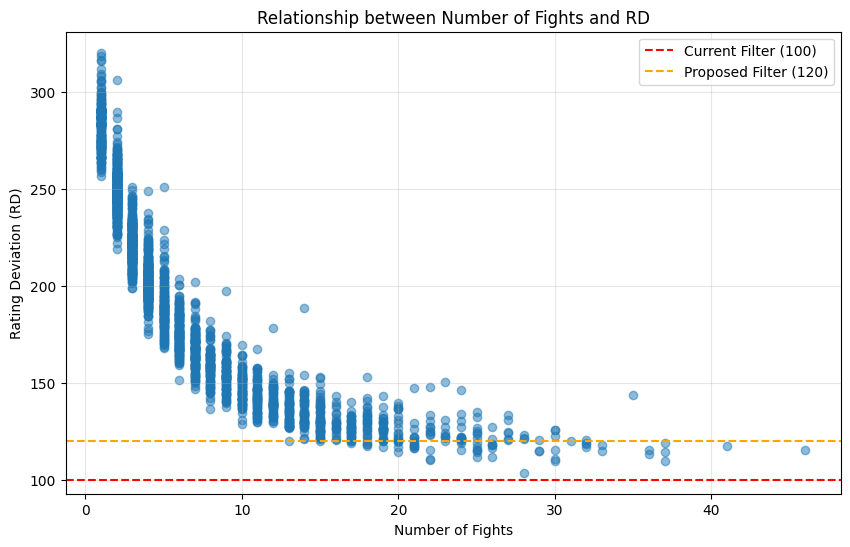

Justin Gaethje RD: 126.24 (Fights: 15)
Average RD for fighters with 15+ fights: 126.77


In [ ]:
# BLOCK 14: Create viz and analyze

# Analyze the relationship between N_FIGHTS and RD
plt.figure(figsize=(10, 6))
plt.scatter(df_current['N_FIGHTS'], df_current['RD'], alpha=0.5)
plt.axhline(y=100, color='r', linestyle='--', label='Current Filter (100)')
plt.axhline(y=120, color='orange', linestyle='--', label='Proposed Filter (120)')
plt.title('Relationship between Number of Fights and RD')
plt.xlabel('Number of Fights')
plt.ylabel('Rating Deviation (RD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gaethje as an example to show that the RD filter at 100 needs adjusting up
# Established fighters, who we can be fairly "sure" of, were being cut
gaethje_rd = df_current[df_current['FIGHTER'] == 'Justin Gaethje']['RD'].iloc[0]
print(f"Justin Gaethje RD: {gaethje_rd:.2f} (Fights: 15)")

avg_rd_15_fights = df_current[df_current['N_FIGHTS'] >= 15]['RD'].mean()
print(f"Average RD for fighters with 15+ fights: {avg_rd_15_fights:.2f}")

### Threshold Adjusting: RD < 125

The average RD for fighters with 15+ UFC bouts is 102.6, meaning the original RD < 100 threshold sat almost exactly at the median for established veterans rather than acting as a confidence boundary. Justin Gaethje (15 fights, RD 104.6) and Khabib Nurmagomedov (13 fights, RD 118.5) both fell just outside the original cutoff despite being plainly established competitors.

Adjusting the threshold to RD < 125 brings both back into the Established tier without allowing low sample fighters. The chosen value is grounded in the empirical RD distribution for fighters with 15+ bouts, not a round number.


In [ ]:
# BLOCK 15: Adjusted Filter

# Run top 25 with adjusted RD filter
top_25_relaxed = df_current[df_current['RD'] < 125].head(25)[['FIGHTER', 'RATING', 'RD', 'N_FIGHTS']]
display(top_25_relaxed)

,FIGHTER,RATING,RD,N_FIGHTS
1606,Alexander Volkanovski,2266.751058,122.844155,18
1739,Merab Dvalishvili,2203.978614,118.972426,17
926,Max Holloway,2192.624725,115.032212,33
1202,Aljamain Sterling,2173.195841,122.619092,23
747,Charles Oliveira,2162.913370,113.476578,36
1217,Sean Strickland,2130.849197,117.339654,25
1783,Petr Yan,2130.525036,122.687681,16
1597,Alexander Volkov,2123.351725,120.223275,19
1766,Magomed Ankalaev,2119.490316,124.336171,15
1982,Brendan Allen,2079.213552,120.874921,19


In [ ]:
# BLOCK 16: RD classification

def classify_rd(rd):
    if rd < 125:
        return 'Established'
    elif rd < 200:
        return 'Provisional'
    else:
        return 'Unreliable'

df_current['TIER'] = df_current['RD'].apply(classify_rd)

print("RD classification:")
print(df_current['TIER'].value_counts().to_string())
print()
print(f"  Established (RD < 125): {(df_current['TIER']=='Established').sum()} fighters")
print(f"  Provisional (125-200):  {(df_current['TIER']=='Provisional').sum()} fighters")
print(f"  Unreliable (RD > 200):  {(df_current['TIER']=='Unreliable').sum()} fighters")

# Save the tier label back to the parquet
df_current.to_parquet(OUTPUT_DIR / 'glicko_current.parquet', index=False)
print(f"\nSaved tier labels back to glicko_current.parquet")

RD classification:
TIER
Unreliable     1369
Provisional    1211
Established     130

  Established (RD < 125): 130 fighters
  Provisional (125-200):  1211 fighters
  Unreliable (RD > 200):  1369 fighters

Saved tier labels back to glicko_current.parquet


## Section 4: Continuous-S dominance modifier

Extend the match score so that the manner of victory, not just the result, informs the rating. The anchors are calibrated and stored, the dominance signals are explored, the continuous-S score is computed per bout, and the rating engine is rerun with it.

### Dominance anchor calibration

The dominance modifier's weights and method baselines are stored in dominance_anchors.yaml as the single source of truth; this block writes them and prints the saved contents so the notebook is self-documenting. Calibration is evidence-based and revisable: the inline values record the post-calibration state, with the earlier values noted alongside (for example the split-decision baseline moved from 0.60 to 0.70, and the win-score floor sits at 0.70). Structural choices are locked; only these calibration parameters are tunable, and their rationale is carried in the report's methodology section. To adjust, edit the YAML and rerun from baseline.

In [ ]:
# BLOCK 17: Save dominance anchors to YAML

# Save dominance modifier configuration to dominance_anchors.yaml. This config
# is the source of truth for the continuous-S scoring weights

# Edit the YAML directly to adjust weights > then rerun from baseline
# post calibration score floor of 0.7 for a win.

DOMINANCE_ANCHORS = {
    'method_baselines': {
    'ko_tko':             0.85,   # post calibration score: unchanged; the finish is the ceiling reference
    'submission':         0.85,   # post calibration score: unchanged
    'doctor_stoppage':    0.80,   # post calibration score: was 0.75
    'decision_unanimous': 0.76,   # post calibration score: was 0.70
    'decision_majority':  0.73,   # post calibration score: was 0.65
    'decision_split':     0.70,   # post calibration score: was 0.60
    'dq':                 0.70,   # post calibration score: was 0.65
},
    'dominance': {
        'max_swing': 0.15,
        'weights': {
            'strike_diff':  0.40,
            'control_diff': 0.30,
            'knockdowns':   0.20,
            'finish_round': 0.10,
        },
            'saturation': {
            'strike_diff':       43,    # was 40; 90th pctile of n=8,894 bouts
            'control_diff':      423,   # was 240; 90th pctile of n=8,894 bouts
            'knockdowns':        1,     # was 2; 95th pctile = 1, multi KD bout rare
            'finish_round_r1':   1.00,
            'finish_round_r2':   0.66,
            'finish_round_r3':   0.33,
            'finish_round_r4_5': 0.10,
        },
    },
    'clipping': {
        'winner_min': 0.50,
        'winner_max': 1.00,
    },
    'meta': {
        'status': 'informed priors with data-calibrated saturation thresholds',
        'last_reviewed': '2026-06-04',
        'calibrated_from': '90th percentile of bouts with round-level coverage',
        'notes': 'Validated against Fight Matrix per-division Spearman correlation.',
    },
}

yaml_path = OUTPUT_DIR / 'dominance_anchors.yaml'
with open(yaml_path, 'w') as f:
    yaml.safe_dump(DOMINANCE_ANCHORS, f, sort_keys=False, default_flow_style=False)

print(f"Saved: {yaml_path}")
print()
print("Contents:")
with open(yaml_path) as f:
    print(f.read())

Saved: /content/drive/MyDrive/Masters in Artificial Intelligence Applied to Sport/Masters Final Project/Pugnator mapper valorem/EDA/Code Outputs/dominance_anchors.yaml

Contents:
method_baselines:
  ko_tko: 0.85
  submission: 0.85
  doctor_stoppage: 0.8
  decision_unanimous: 0.76
  decision_majority: 0.73
  decision_split: 0.7
  dq: 0.7
dominance:
  max_swing: 0.15
  weights:
    strike_diff: 0.4
    control_diff: 0.3
    knockdowns: 0.2
    finish_round: 0.1
  saturation:
    strike_diff: 43
    control_diff: 423
    knockdowns: 1
    finish_round_r1: 1.0
    finish_round_r2: 0.66
    finish_round_r3: 0.33
    finish_round_r4_5: 0.1
clipping:
  winner_min: 0.5
  winner_max: 1.0
meta:
  status: informed priors with data-calibrated saturation thresholds
  last_reviewed: '2026-06-04'
  calibrated_from: 90th percentile of bouts with round-level coverage
  notes: Validated against Fight Matrix per-division Spearman correlation.



### Dominance modifier tuning history

**v1 (2026-06-04):** Initial calibration with data-derived saturation thresholds.
- Method baselines from informed priors (see proposal methodology section)
- Saturation: 90th percentile of n=8,894 bouts
- Weights: strike_diff 0.40, control_diff 0.30, knockdowns 0.20, finish_round 0.10
- Status: feeds the continuous-S Glicko-2 run below

Future tuning entries will follow this format when adjustments are made.

In [ ]:
# BLOCK 18: Explore dominance signals

# Calibration of dominance saturation thresholds.


# Build df
stats_path = OUTPUT_DIR / 'fight_stats_numeric.parquet'
df_stats = pd.read_parquet(stats_path)

# Aggregate round stats to fighter level
agg_cols = {
    'SIG.STR._landed':    'sum',
    'SIG.STR._attempted': 'sum',
    'TD_landed':          'sum',
    'CTRL_secs':          'sum',
    'KD_num':             'sum',
    'SUB.ATT_num':        'sum',
    'ROUND_int':          'max',
}
agg_cols = {k: v for k, v in agg_cols.items() if k in df_stats.columns}

df_bout_stats = df_stats.groupby(['EVENT', 'BOUT', 'FIGHTER']).agg(agg_cols).reset_index()
df_bout_stats = df_bout_stats.rename(columns={'ROUND_int': 'LAST_ROUND'})

# Join to bout outcomes
# merge on FIGHT_ID as df_fights does not have 'BOUT'

# First, add FIGHT_ID to df_bout_stats
fight_id_map = df_fights[['EVENT', 'FIGHTER', 'FIGHT_ID']].drop_duplicates()
df_bout_stats = df_bout_stats.merge(fight_id_map, on=['EVENT', 'FIGHTER'], how='left')

df_joined = df_fights.merge(
    df_bout_stats,
    on=['FIGHT_ID', 'FIGHTER'], # Changed merge keys to FIGHT_ID and FIGHTER
    how='left'  # keep all modelable bouts; missing round stats become NaN
)

# Pair winners and losers per FIGHT_ID
winners = df_joined[df_joined['SCORE'] > 0.5].copy()
losers  = df_joined[df_joined['SCORE'] < 0.5].copy()
df_pairs = winners.merge(losers, on='FIGHT_ID', suffixes=('_W', '_L'))

# Differentials
df_pairs['strike_diff']  = df_pairs['SIG.STR._landed_W'] - df_pairs['SIG.STR._landed_L']
df_pairs['control_diff'] = df_pairs['CTRL_secs_W']       - df_pairs['CTRL_secs_L']
df_pairs['kd_diff']      = df_pairs['KD_num_W']          - df_pairs['KD_num_L']
df_pairs['finish_round'] = df_pairs['LAST_ROUND_W']
df_pairs['method_cat']   = df_pairs['METHOD_CAT_W']
df_pairs['method']       = df_pairs['METHOD_W']
df_pairs['weightclass']  = df_pairs['WEIGHTCLASS_W']
df_pairs['era']          = df_pairs['ERA_W']
df_pairs['date']         = df_pairs['DATE_PARSED_W']

# Exclude fights with no round data
df_pairs_with_stats = df_pairs.dropna(subset=['strike_diff', 'control_diff', 'kd_diff']).copy()

print(f"Fights total: {len(df_pairs):,}")
print(f"Fights with round data: {len(df_pairs_with_stats):,}")

# Save for repeated use
pairs_path = OUTPUT_DIR / 'bout_pairs.parquet'
df_pairs_with_stats.to_parquet(pairs_path, index=False)
print(f"Saved: {pairs_path}")

Fights total: 8,915
Fights with round data: 8,894
Saved: /content/drive/MyDrive/Masters in Artificial Intelligence Applied to Sport/Masters Final Project/Pugnator mapper valorem/EDA/Code Outputs/bout_pairs.parquet


Sig strikes landed (winner - loser)  (n=8,894 bouts)
  median:       10.0
  mean:         14.6
  75th pctile:  25.0
  90th pctile:  42.7
  95th pctile:  56.0


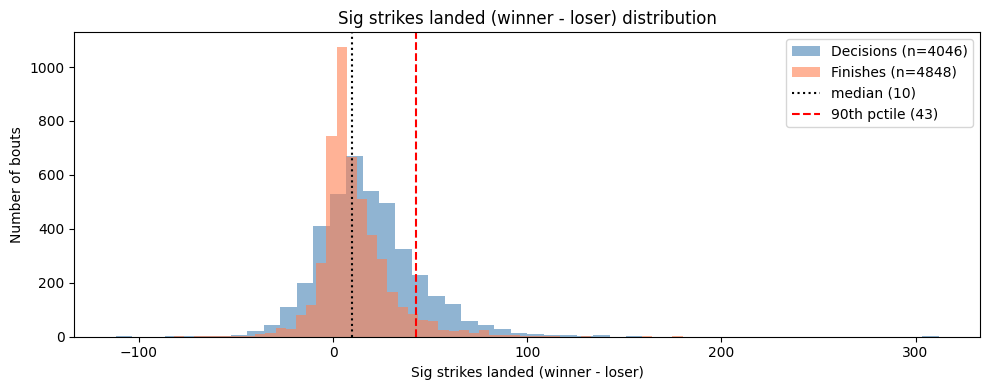


By method category (median, mean, n):
            median  mean  count
method_cat                     
decision      16.0  18.6   4046
dq            -6.0  -6.5     23
finish         8.0  11.4   4825
Control time seconds (winner - loser)  (n=8,894 bouts)
  median:       26.0
  mean:         95.9
  75th pctile:  194.0
  90th pctile:  423.0
  95th pctile:  557.0


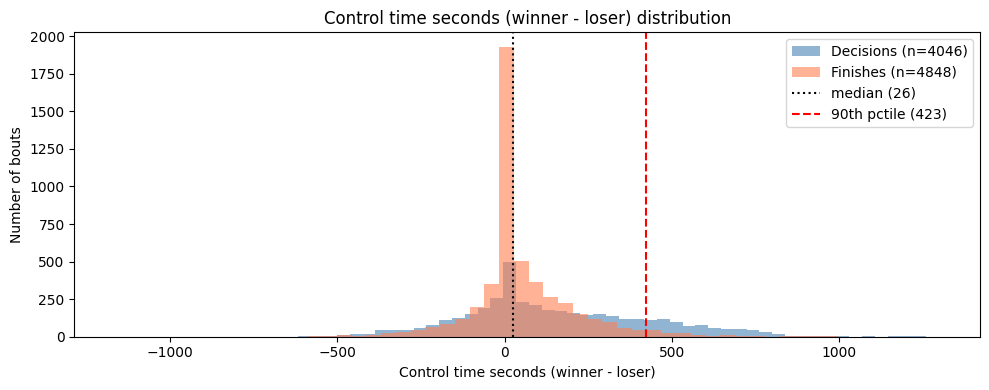


By method category (median, mean, n):
            median   mean  count
method_cat                      
decision      96.0  151.3   4046
dq           -13.0   13.6     23
finish         8.0   49.9   4825
Knockdowns (winner - loser)  (n=8,894 bouts)
  median:       0.0
  mean:         0.3
  75th pctile:  1.0
  90th pctile:  1.0
  95th pctile:  1.0


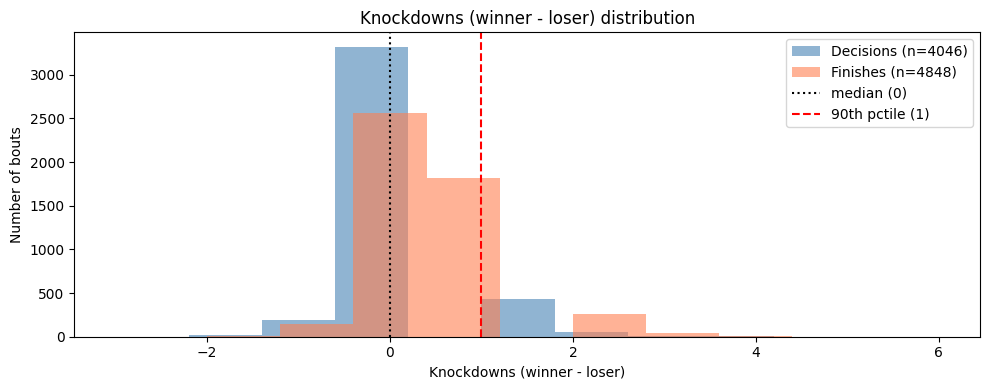


By method category (median, mean, n):
            median  mean  count
method_cat                     
decision       0.0   0.1   4046
dq             0.0  -0.3     23
finish         0.0   0.5   4825


In [ ]:
# BLOCK 19: Plot dominance signal distributions


def explore_signal(df, signal, label, bins=50, by_method=True, show_percentiles=True):
# Plot a dominance signal's distribution with optional method breakdown.
    vals = df[signal].dropna()

    print(f"{label}  (n={len(vals):,} bouts)")
    print(f"  median:       {vals.median():.1f}")
    print(f"  mean:         {vals.mean():.1f}")
    print(f"  75th pctile:  {vals.quantile(0.75):.1f}")
    print(f"  90th pctile:  {vals.quantile(0.90):.1f}")
    print(f"  95th pctile:  {vals.quantile(0.95):.1f}")

    fig, ax = plt.subplots(figsize=(10, 4))

    if by_method and 'method_cat' in df.columns:
        # Separate distributions for decisions vs finishes
        decisions = df[df['method_cat'] == 'decision'][signal].dropna()
        finishes  = df[df['method_cat'].isin(['finish', 'dq'])][signal].dropna()
        ax.hist(decisions, bins=bins, alpha=0.6, label=f'Decisions (n={len(decisions)})', color='steelblue')
        ax.hist(finishes,  bins=bins, alpha=0.6, label=f'Finishes (n={len(finishes)})', color='coral')
        ax.legend()
    else:
        ax.hist(vals, bins=bins, alpha=0.7, color='steelblue')

    if show_percentiles:
        ax.axvline(vals.quantile(0.50), color='black', linestyle=':',  label=f'median ({vals.quantile(0.50):.0f})')
        ax.axvline(vals.quantile(0.90), color='red',   linestyle='--', label=f'90th pctile ({vals.quantile(0.90):.0f})')

    ax.set_xlabel(label)
    ax.set_ylabel('Number of bouts')
    ax.set_title(f'{label} distribution')
    ax.legend()
    plt.tight_layout()
    plt.show()

    if 'method_cat' in df.columns:
        print(f"\nBy method category (median, mean, n):")
        print(df.groupby('method_cat')[signal].agg(['median', 'mean', 'count']).round(1))

# Examples
explore_signal(df_pairs_with_stats, 'strike_diff',  'Sig strikes landed (winner - loser)')
explore_signal(df_pairs_with_stats, 'control_diff', 'Control time seconds (winner - loser)')
explore_signal(df_pairs_with_stats, 'kd_diff',      'Knockdowns (winner - loser)', bins=10)


Finish distribution by round (n=4,848 finishes):
finish_round
1.0    0.551361
2.0    0.290429
3.0    0.140677
4.0    0.010520
5.0    0.007013


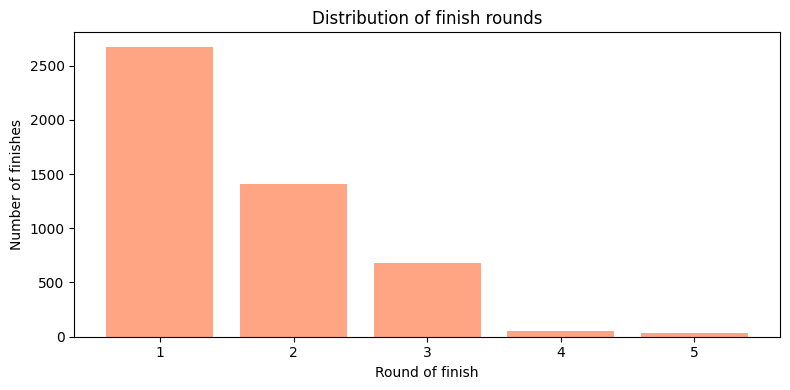

In [ ]:
# BLOCK 20: Round of finish distribution
finishes = df_pairs_with_stats[df_pairs_with_stats['method_cat'].isin(['finish', 'dq'])]
print(f"\nFinish distribution by round (n={len(finishes):,} finishes):")
print(finishes['finish_round'].value_counts(normalize=True).sort_index().to_string())

fig, ax = plt.subplots(figsize=(8, 4))
counts = finishes['finish_round'].value_counts().sort_index()
ax.bar(counts.index.astype(int), counts.values, color='coral', alpha=0.7)
ax.set_xlabel('Round of finish')
ax.set_ylabel('Number of finishes')
ax.set_title('Distribution of finish rounds')
plt.tight_layout()
plt.show()

In [ ]:
# BLOCK 21: Continuous-S dominance scores

# Load the calibrated dominance anchors from YAML. For each bout:
#   Look up the method baseline
#   Calculate each dominance signal
#   Sum the signals (weighted), clip to max_swing
#   Add to the method baseline, clip to [winner_min, winner_max]
#   Loser's score is 1 - winner's score

# Bouts without round-level coverage fall back to a plain binary score
# (1.0 / 0.0 / 0.5)

# Load Calibrated anchors
with open(OUTPUT_DIR / 'dominance_anchors.yaml') as f:
    anchors = yaml.safe_load(f)

method_baselines = anchors['method_baselines']
weights          = anchors['dominance']['weights']
saturation       = anchors['dominance']['saturation']
max_swing        = anchors['dominance']['max_swing']
winner_min       = anchors['clipping']['winner_min']
winner_max       = anchors['clipping']['winner_max']

print("Loaded anchors:")
print(f"  Method baselines: {method_baselines}")
print(f"  Weights: {weights}")
print(f"  Saturation: {saturation}")
print(f"  Max swing: ±{max_swing}, clip range: [{winner_min}, {winner_max}]")
print()

# Load paired data from parquet
df_pairs = pd.read_parquet(OUTPUT_DIR / 'bout_pairs.parquet')
print(f"Loaded {len(df_pairs):,} pair rows with round-level coverage")

Loaded anchors:
  Method baselines: {'ko_tko': 0.85, 'submission': 0.85, 'doctor_stoppage': 0.8, 'decision_unanimous': 0.76, 'decision_majority': 0.73, 'decision_split': 0.7, 'dq': 0.7}
  Weights: {'strike_diff': 0.4, 'control_diff': 0.3, 'knockdowns': 0.2, 'finish_round': 0.1}
  Saturation: {'strike_diff': 43, 'control_diff': 423, 'knockdowns': 1, 'finish_round_r1': 1.0, 'finish_round_r2': 0.66, 'finish_round_r3': 0.33, 'finish_round_r4_5': 0.1}
  Max swing: ±0.15, clip range: [0.5, 1.0]

Loaded 8,894 pair rows with round-level coverage


In [ ]:
# BLOCK 22: Map METHOD to YAML baseline keys

# The method strings in the data are 'KO/TKO', 'Submission',
# 'Decision - Unanimous', etc. The YAML keys are normalised to ko_tko,
# decision_unanimous etc.

# Map METHOD string to a YAML baseline key
def method_to_baseline_key(method_str):
    if pd.isna(method_str):
        return None
    m = str(method_str).lower()

    # Check 'decision - X' variants before 'decision'
    if 'decision' in m and 'unanimous' in m:
        return 'decision_unanimous'
    if 'decision' in m and 'majority' in m:
        return 'decision_majority'
    if 'decision' in m and 'split' in m:
        return 'decision_split'
    if 'decision' in m:
        return 'decision_unanimous'  # just in case :)
    if 'submission' in m:
        return 'submission'
    if "doctor" in m or 'stoppage' in m:
        return 'doctor_stoppage'
    if 'ko' in m or 'tko' in m:
        return 'ko_tko'
    if 'dq' in m or 'disqualif' in m:
        return 'dq'
    return None

# Test mapping vs the METHOD strings
methods_in_data = df_pairs['method'].dropna().unique()
print("Method string > baseline key mapping:")
unmapped = []
for m in sorted(methods_in_data):
    key = method_to_baseline_key(m)
    flag = f"> {key}" if key else "> UNMAPPED"
    if key is None:
        unmapped.append(m)
    print(f"  {m[:50]:50s} {flag}")

if unmapped:
    print(f"\nERROR: {len(unmapped)} method strings unmapped. Binary scoring used as a fallback.")

Method string > baseline key mapping:
  DQ                                                 > dq
  Decision - Majority                                > decision_majority
  Decision - Split                                   > decision_split
  Decision - Unanimous                               > decision_unanimous
  KO/TKO                                             > ko_tko
  Submission                                         > submission
  TKO - Doctor's Stoppage                            > doctor_stoppage


In [ ]:
# BLOCK 23: Calculate continuous-S score for each fight

# Compute for one bout
def compute_continuous_s(row):
    # Method baseline
    key = method_to_baseline_key(row['method'])
    if key is None or key not in method_baselines:
        return None

    # Dominance components, scaled to saturation value and capped at 1
    sd_share = min(1.0, max(0.0, row['strike_diff']  / saturation['strike_diff']))
    cd_share = min(1.0, max(0.0, row['control_diff'] / saturation['control_diff']))
    kd_share = min(1.0, max(0.0, row['kd_diff']      / saturation['knockdowns']))

    # Finishes by round share
    finish_round = row['finish_round']
    if pd.isna(finish_round) or row['method_cat'] == 'decision':
        fr_share = 0.0
    elif finish_round == 1:
        fr_share = saturation['finish_round_r1']
    elif finish_round == 2:
        fr_share = saturation['finish_round_r2']
    elif finish_round == 3:
        fr_share = saturation['finish_round_r3']
    else:
        fr_share = saturation['finish_round_r4_5']

    # Weighted total of contributions (scaled by max_swing)
    weighted_share = (
        weights['strike_diff']  * sd_share +
        weights['control_diff'] * cd_share +
        weights['knockdowns']   * kd_share +
        weights['finish_round'] * fr_share
    )
    adjustment = weighted_share * max_swing

    # Apply to baseline then clip
    score = method_baselines[key] + adjustment
    score = min(winner_max, max(winner_min, score))
    return score

# Apply to all fights
df_pairs['winner_score'] = df_pairs.apply(compute_continuous_s, axis=1)
df_pairs['loser_score']  = 1.0 - df_pairs['winner_score']

# Work out amount of fights with a continuous score
n_scored = df_pairs['winner_score'].notna().sum()
n_unscored = df_pairs['winner_score'].isna().sum()
print(f"Bouts scored with continuous-S: {n_scored:,}")
print(f"Bouts using binary fallback: {n_unscored:,}")
print()

# Check distribution
scored = df_pairs['winner_score'].dropna()
print("Winner score distribution (Continuous):")
print(scored.describe().round(3).to_string())

Bouts scored with continuous-S: 8,894
Bouts using binary fallback: 0

Winner score distribution (Continuous):
count    8894.000
mean        0.850
std         0.063
min         0.700
25%         0.805
50%         0.865
75%         0.901
max         0.995


Score distribution by method of victory:
             count   mean    std    min    25%    50%    75%    max
method_cat                                                         
decision    4046.0  0.794  0.044  0.700  0.766  0.802  0.822  0.895
dq            23.0  0.724  0.022  0.705  0.715  0.715  0.720  0.785
finish      4825.0  0.898  0.027  0.805  0.876  0.898  0.914  0.995



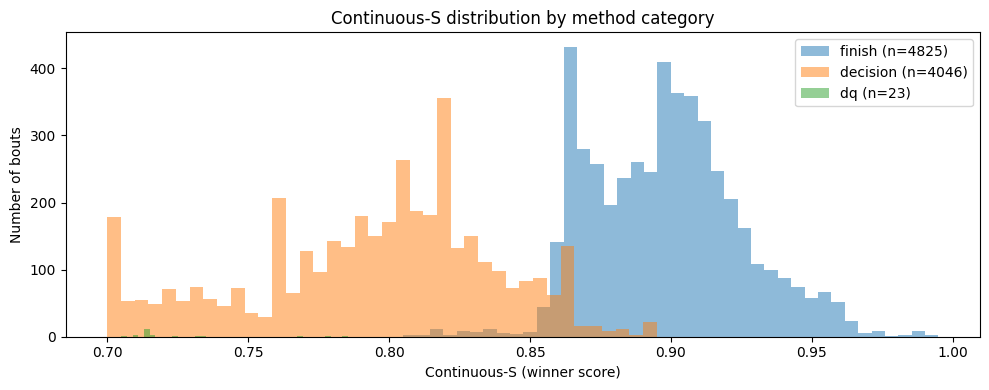

Top 5 highest-scored wins (most dominant):
      date      FIGHTER_W      FIGHTER_L method  strike_diff  control_diff  kd_diff  finish_round  winner_score
2006-06-28      Jon Fitch   Thiago Alves KO/TKO         50.0         501.0      1.0           2.0       0.99490
2011-03-03     Dongi Yang    Rob Kimmons KO/TKO         56.0         471.0      1.0           2.0       0.99490
2002-06-22  Tony Fryklund   Rodrigo Ruas KO/TKO         49.0         412.0      1.0           2.0       0.99373
2011-03-19      Jon Jones   Mauricio Rua KO/TKO         66.0         467.0      1.0           3.0       0.98995
2011-12-03 Johnny Bedford Louis Gaudinot KO/TKO         76.0         561.0      1.0           3.0       0.98995

Bottom 5 winner scores (narrowest wins):
      date    FIGHTER_W         FIGHTER_L           method  strike_diff  control_diff  kd_diff  finish_round  winner_score
1996-05-17   Dan Severn      Ken Shamrock Decision - Split         -2.0           0.0      0.0           3.0           0

In [ ]:
# BLOCK 24: Verify distributions by method

# Confirm the scores actually cluster as designed.

print("Score distribution by method of victory:")
print(df_pairs.groupby('method_cat')['winner_score'].describe().round(3))
print()

# Histogram
fig, ax = plt.subplots(figsize=(10, 4))

for cat in df_pairs['method_cat'].dropna().unique():
    subset = df_pairs[df_pairs['method_cat'] == cat]['winner_score'].dropna()
    if len(subset) > 0:
        ax.hist(subset, bins=40, alpha=0.5, label=f'{cat} (n={len(subset)})')

ax.set_xlabel('Continuous-S (winner score)')
ax.set_ylabel('Number of bouts')
ax.set_title('Continuous-S distribution by method category')
ax.legend()
plt.tight_layout()
plt.show()

# Xtreme examples
print("Top 5 highest-scored wins (most dominant):")
top = df_pairs.nlargest(5, 'winner_score')[
    ['date', 'FIGHTER_W', 'FIGHTER_L', 'method', 'strike_diff', 'control_diff', 'kd_diff', 'finish_round', 'winner_score']
]
print(top.to_string(index=False))
print()
print("Bottom 5 winner scores (narrowest wins):")
bot = df_pairs.nsmallest(5, 'winner_score')[
    ['date', 'FIGHTER_W', 'FIGHTER_L', 'method', 'strike_diff', 'control_diff', 'kd_diff', 'finish_round', 'winner_score']
]
print(bot.to_string(index=False))

In [ ]:
# BLOCK 25: Check modern bottom 5 (post-2015) where full round data is available


modern_pairs = df_pairs[df_pairs['date'] >= '2015-01-01']
bot_modern = modern_pairs.nsmallest(5, 'winner_score')[
    ['date', 'FIGHTER_W', 'FIGHTER_L', 'method',
     'strike_diff', 'control_diff', 'kd_diff', 'finish_round', 'winner_score']
]
print("Bottom 5 winner scores (post-2015 only):")
print(bot_modern.to_string(index=False))

Bottom 5 winner scores (post-2015 only):
      date      FIGHTER_W       FIGHTER_L           method  strike_diff  control_diff  kd_diff  finish_round  winner_score
2015-01-24     Ryan Bader      Phil Davis Decision - Split         -9.0         -43.0      0.0           3.0           0.7
2015-01-31  Tyron Woodley Kelvin Gastelum Decision - Split         -5.0         -15.0      0.0           3.0           0.7
2015-02-28  Valmir Lazaro    James Krause Decision - Split          0.0         -79.0      0.0           3.0           0.7
2015-04-04    Al Iaquinta  Jorge Masvidal Decision - Split        -28.0         -18.0      0.0           3.0           0.7
2015-05-16 Phillipe Nover    Yui Chul Nam Decision - Split        -17.0         -12.0      0.0           3.0           0.7


In [ ]:
# BLOCK 26: Rerun model with continuous-S scores

# Replace the binary SCORE with the continuous-S score
# Outputs are saved to *_continuous parquet files

# Build (FIGHT_ID, FIGHTER) > continuous_score lookup
score_lookup = {}
for _, row in df_pairs.iterrows():
    fight_id = row['FIGHT_ID']
    # Winner and loser names live in the suffixed columns
    winner_name = row['FIGHTER_W']
    loser_name = row['FIGHTER_L']
    w_score = row['winner_score']
    l_score = row['loser_score']
    # Only use if a continuous score is present
    if pd.notna(w_score):
        score_lookup[(fight_id, winner_name)] = w_score
        score_lookup[(fight_id, loser_name)] = l_score

print(f"Continuous score lookup built with {len(score_lookup):,} entries")
print(f"  (covers {len(score_lookup)//2:,} fights; remainder fall back to binary)")
print()

# Build continuous fighter df
df_fights_continuous = df_fights.copy()
df_fights_continuous['SCORE'] = df_fights_continuous.apply(
    lambda r: score_lookup.get((r['FIGHT_ID'], r['FIGHTER']), r['SCORE']),
    axis=1
)

# Did any fights keep the binary score?
n_changed = (df_fights_continuous['SCORE'] != df_fights['SCORE']).sum()
n_unchanged = (df_fights_continuous['SCORE'] == df_fights['SCORE']).sum()
print(f"Score values changed (continuous-S applied): {n_changed:,}")
print(f"Score values unchanged (binary fallback):    {n_unchanged:,}")
print(f"  (this includes draws where 0.5 stayed 0.5, and bouts with no round coverage)")
print()

# Sort chronologically
df_fights_continuous = df_fights_continuous.sort_values(['DATE_PARSED', 'FIGHT_ID']).reset_index(drop=True)
bouts_continuous = df_fights_continuous.groupby('FIGHT_ID', sort=False)

Continuous score lookup built with 17,192 entries
  (covers 8,596 fights; remainder fall back to binary)

Score values changed (continuous-S applied): 17,192
Score values unchanged (binary fallback):    166
  (this includes draws where 0.5 stayed 0.5, and bouts with no round coverage)



In [ ]:
# BLOCK 27: Run the rating loop with continuous scores

fighter_state_c = {}    # _c suffix = continuous version
history_c = []

def get_or_init_c(name):
    if name not in fighter_state_c:
        fighter_state_c[name] = {
            'mu': MU, 'phi': PHI, 'sigma': SIGMA, 'last_date': None
        }
    return fighter_state_c[name]

n_processed = 0

for fight_id, bout_rows in bouts_continuous:
    if len(bout_rows) != 2:
        continue

    row_a, row_b = bout_rows.iloc[0], bout_rows.iloc[1]
    fight_date = row_a['DATE_PARSED']

    if pd.isna(fight_date):
        continue

    name_a, name_b = row_a['FIGHTER'], row_b['FIGHTER']
    score_a, score_b = row_a['SCORE'], row_b['SCORE']

    state_a = get_or_init_c(name_a)
    state_b = get_or_init_c(name_b)

    # Inactivity decay
    if state_a['last_date'] is not None:
        elapsed_a = (fight_date - state_a['last_date']).days
        state_a['phi'] = apply_inactivity_decay(state_a['phi'], state_a['sigma'], elapsed_a)
    if state_b['last_date'] is not None:
        elapsed_b = (fight_date - state_b['last_date']).days
        state_b['phi'] = apply_inactivity_decay(state_b['phi'], state_b['sigma'], elapsed_b)

    # Snapshot pre fight state
    pre_a = (state_a['mu'], state_a['phi'], state_a['sigma'])
    pre_b = (state_b['mu'], state_b['phi'], state_b['sigma'])

    # Calculate both updates from the snapshot
    mu_a_new, phi_a_new, sigma_a_new = update_rating(
        pre_a[0], pre_a[1], pre_a[2],
        opponents=[(pre_b[0], pre_b[1])],
        outcomes=[score_a]
    )
    mu_b_new, phi_b_new, sigma_b_new = update_rating(
        pre_b[0], pre_b[1], pre_b[2],
        opponents=[(pre_a[0], pre_a[1])],
        outcomes=[score_b]
    )

    # Write state
    state_a['mu'], state_a['phi'], state_a['sigma'] = mu_a_new, phi_a_new, sigma_a_new
    state_a['last_date'] = fight_date
    state_b['mu'], state_b['phi'], state_b['sigma'] = mu_b_new, phi_b_new, sigma_b_new
    state_b['last_date'] = fight_date

    # Log history
    rating_a_pre, rd_a_pre = scale_up(pre_a[0], pre_a[1])
    rating_a_post, rd_a_post = scale_up(mu_a_new, phi_a_new)
    rating_b_pre, rd_b_pre = scale_up(pre_b[0], pre_b[1])
    rating_b_post, rd_b_post = scale_up(mu_b_new, phi_b_new)

    history_c.append({
        'FIGHT_ID': fight_id, 'DATE': fight_date, 'FIGHTER': name_a,
        'OPPONENT': name_b, 'SCORE': score_a,
        'RATING_PRE': rating_a_pre, 'RD_PRE': rd_a_pre,
        'RATING_POST': rating_a_post, 'RD_POST': rd_a_post,
        'SIGMA_POST': sigma_a_new,
    })
    history_c.append({
        'FIGHT_ID': fight_id, 'DATE': fight_date, 'FIGHTER': name_b,
        'OPPONENT': name_a, 'SCORE': score_b,
        'RATING_PRE': rating_b_pre, 'RD_PRE': rd_b_pre,
        'RATING_POST': rating_b_post, 'RD_POST': rd_b_post,
        'SIGMA_POST': sigma_b_new,
    })
    n_processed += 1

print(f"Fights processed: {n_processed:,}")
print(f"Fighters rated:  {len(fighter_state_c):,}")
print(f"History rows:    {len(history_c):,}")

Fights processed: 8,679
Fighters rated:  2,710
History rows:    17,358


The continuous-S score replaces the binary win/loss score for 17,192 of the 17,358 fighter-bout entries (99%). The 166 that keep the binary score are draws (where 0.5 remains 0.5) and older bouts with no round-level coverage from which a dominance score cannot be computed. The fallback is therefore principled rather than a gap: every bout that can carry a continuous score does, and the remainder default to the binary outcome.

In [ ]:
# BLOCK 28: Save continuous-S outputs

df_history_c = pd.DataFrame(history_c)

current_rows_c = []
for name, s in fighter_state_c.items():
    rating, rd = scale_up(s['mu'], s['phi'])
    current_rows_c.append({
        'FIGHTER': name,
        'RATING': rating,
        'RD': rd,
        'SIGMA': s['sigma'],
        'LAST_FIGHT': s['last_date'],
    })
df_current_c = pd.DataFrame(current_rows_c).sort_values('RATING', ascending=False)

# Add fight counts and tier classification
fight_counts_c = df_history_c['FIGHTER'].value_counts().rename('N_FIGHTS')
df_current_c = df_current_c.merge(fight_counts_c, left_on='FIGHTER', right_index=True, how='left')
df_current_c['TIER'] = df_current_c['RD'].apply(classify_rd)

# Save to Drive
df_current_c.to_parquet(OUTPUT_DIR / 'glicko_current_continuous.parquet', index=False)
df_history_c.to_parquet(OUTPUT_DIR / 'glicko_history_continuous.parquet', index=False)

print(f"Saved: glicko_current_continuous.parquet ({len(df_current_c):,} fighters)")
print(f"Saved: glicko_history_continuous.parquet ({len(df_history_c):,} rows)")
print()

# Preview
print("TOP 25 (continuous-S, all RDs):")
print(df_current_c.head(25)[['FIGHTER', 'RATING', 'RD', 'N_FIGHTS', 'TIER']].to_string(index=False))

NameError: name 'history_c' is not defined

The continuous-S dominance modifier rescales the rating distribution rather than shifting it uniformly: because the match score now varies with the manner of victory rather than sitting at a fixed win value, the absolute ratings under the two runs are not directly comparable, and the modifier's effect is best read through relative standing and the reliability tiers rather than raw point differences. In the top group under the continuous-S run, fighters with finish-heavy records and fighters who accumulated their records through technical decisions sit differently than they do under plain Glicko-2, consistent with the modifier's design intent of rewarding demonstrated dominance over a bare result. A direct rank-movement comparison between the two runs is noted as a further diagnostic in the future work register.


## Section 5: Diagnostics

Sanity-check the rating outputs: ranking by division, the effect of division change, the inactivity decay on known cases, and the overall population shape.

In [ ]:
# BLOCK 29: Check by Division Top 10

# Add latest weight class
latest_wc = (
    df_fights.sort_values('DATE_PARSED')
    .groupby('FIGHTER')['WEIGHTCLASS_CANONICAL']
    .last()
)
df_current_c['LATEST_WC'] = df_current_c['FIGHTER'].map(latest_wc)

# filter to recent activity
latest_date_in_data = df_fights['DATE_PARSED'].max()
cutoff_date = latest_date_in_data - pd.Timedelta(days=3 * 365)
df_active = df_current_c[df_current_c['LAST_FIGHT'] >= cutoff_date].copy()
print(f"Active fighters (since {cutoff_date.date()}): {len(df_active):,}")
print()

# divisions.
DIVISIONS = [
    ('Heavyweight',           "Heavyweight"),
    ('Light Heavyweight',     "Light Heavyweight"),
    ('Middleweight',          "Middleweight"),
    ('Welterweight',          "Welterweight"),
    ('Lightweight',           "Lightweight"),
    ('Featherweight',         "Featherweight"),
    ('Bantamweight',          "Bantamweight"),
    ('Flyweight',             "Flyweight"),
    ("Women's Strawweight",   "Women's Strawweight"),
    ("Women's Flyweight",     "Women's Flyweight"),
    ("Women's Bantamweight",  "Women's Bantamweight"),
]

# top 10 per division
for display_name, match_str in DIVISIONS:
    # Women's' divisions need to be matched before the men's to avoid errors
    # e.g. "Women's Bantamweight" being mixed with "Bantamweight".
    is_womens_division = match_str.startswith("Women's")

    if is_womens_division:
        mask = df_active['LATEST_WC'].str.contains(match_str, case=False, na=False)
    elif match_str == 'Heavyweight':
        mask = (
            df_active['LATEST_WC'].str.contains('Heavyweight', case=False, na=False)
            & ~df_active['LATEST_WC'].str.contains('Light Heavyweight', case=False, na=False)
            & ~df_active['LATEST_WC'].str.contains("Women", case=False, na=False)
        )
    else:
        mask = (
            df_active['LATEST_WC'].str.contains(match_str, case=False, na=False)
            & ~df_active['LATEST_WC'].str.contains("Women", case=False, na=False)
        )

    division_fighters = df_active[mask].sort_values('RATING', ascending=False).head(10)

    if len(division_fighters) == 0:
        print(f"\n=== {display_name} ===  (no active fighters found)\n")
        continue

    print(f"\n{display_name} (top 10 active, since {cutoff_date.date()})")
    print(division_fighters[['FIGHTER', 'RATING', 'RD', 'N_FIGHTS', 'TIER']].to_string(index=False))

NameError: name 'df_current_c' is not defined

In [ ]:
# BLOCK 30: WEIGHT CHANGE DIAGNOSTIC

# Analyse score changes post weight class change...does the data suggest a decay
# is needed on the score for those changing weight?

# Reload the parquet (it has the new WEIGHTCLASS_CANONICAL column)
df_fights = pd.read_parquet(OUTPUT_DIR / 'fights_per_fighter.parquet')

# Check the column exists
assert 'WEIGHTCLASS_CANONICAL' in df_fights.columns, \
    "WEIGHTCLASS_CANONICAL not found; rerun notebook 07's save cell."
print(f"Loaded parquet with WEIGHTCLASS_CANONICAL column ({len(df_fights):,} rows)")

# Identify fighters with > 1 distinct CANONICAL division
fighter_divisions = (
    df_fights.groupby('FIGHTER')['WEIGHTCLASS_CANONICAL']
    .apply(lambda x: x.dropna().unique())
)
movers = fighter_divisions[fighter_divisions.apply(len) > 1]

print(f"Total fighters: {len(fighter_divisions):,}")
print(f"Fighters who fought in >1 CANONICAL division: {len(movers):,}")
print()

# Compare ratings before/after
move_records = []

for fighter, divs in movers.items():
    fh = df_history_c[df_history_c['FIGHTER'] == fighter].sort_values('DATE').reset_index(drop=True)
    if len(fh) < 6:
        continue

    # Pull this fighter's division sequence
    fights = df_fights[df_fights['FIGHTER'] == fighter].sort_values('DATE_PARSED')
    wcs = fights['WEIGHTCLASS_CANONICAL'].reset_index(drop=True)

    if len(wcs) != len(fh):
        continue

    # Find the index of the first canonical division change
    for i in range(1, len(wcs)):
        if pd.notna(wcs[i]) and pd.notna(wcs[i-1]) and wcs[i] != wcs[i-1]:
            if i >= 5 and (len(fh) - i) >= 5:
                before = fh.iloc[i-5:i]['RATING_POST'].mean()
                after = fh.iloc[i:i+5]['RATING_POST'].mean()
                move_records.append({
                    'FIGHTER': fighter,
                    'FROM': wcs[i-1],
                    'TO': wcs[i],
                    'RATING_BEFORE_MOVE_AVG': before,
                    'RATING_AFTER_MOVE_AVG': after,
                    'DIFF': after - before,
                    'MOVE_FIGHT_INDEX': i,
                })
            break

df_moves = pd.DataFrame(move_records)
print(f"Events analysed: {len(df_moves):,}")
print()
print("Rating change across canonical division moves:")
print(df_moves['DIFF'].describe().round(1).to_string())
print()
print("Most negative moves (rating dropped most):")
print(df_moves.sort_values('DIFF').head(10).to_string(index=False))
print()
print("Most positive moves (rating climbed most):")
print(df_moves.sort_values('DIFF', ascending=False).head(10).to_string(index=False))

Loaded parquet with WEIGHTCLASS_CANONICAL column (17,358 rows)
Total fighters: 2,710
Fighters who fought in >1 CANONICAL division: 965



NameError: name 'df_history_c' is not defined

In [ ]:
# BLOCK 31: build the canonical fighter by division table for the dashboard

df_fights = pd.read_parquet(OUTPUT_DIR / 'fights_per_fighter.parquet')

# division fields source from the bouts with a known canonical weight class.
_div = df_fights.dropna(subset=['WEIGHTCLASS_CANONICAL']).copy()

# primary division: the weight class a fighter has fought in most often.
# value_counts orders by frequency, so the first index is the modal division.
def _modal_division(g):
    return g['WEIGHTCLASS_CANONICAL'].value_counts().index[0]

# last fight division: the weight class of the most recent bout.
def _last_division(g):
    return g.sort_values('DATE_PARSED')['WEIGHTCLASS_CANONICAL'].iloc[-1]

# recent form is read from all dated bouts, not only those with a canonical
# weight class, so it is built from a separate per-fighter grouping. precompute
# a form string per fighter once, then look it up, rather than rescanning the
# frame for every fighter.
_form_src = df_fights.dropna(subset=['DATE_PARSED']).sort_values('DATE_PARSED')
recent_form_map = (
    _form_src.groupby('FIGHTER')['RESULT']
    .apply(lambda s: '-'.join(s.tail(5).tolist()))
    .to_dict()
)

records = []
for fighter, g in _div.groupby('FIGHTER'):
    divs_list = sorted(g['WEIGHTCLASS_CANONICAL'].unique())
    records.append({
        'FIGHTER': fighter,
        'primary_division': _modal_division(g),
        'last_division': _last_division(g),
        'divs': divs_list,
        'recent_form': recent_form_map.get(fighter, ''),
    })

fighter_divisions_df = pd.DataFrame(records)

# keep wc column mirroring the primary division so existing app references stay valid
fighter_divisions_df['wc'] = fighter_divisions_df['primary_division']

# checks and save
assert fighter_divisions_df['FIGHTER'].is_unique, "duplicate fighters in division table"
assert fighter_divisions_df['primary_division'].notna().all(), "missing primary division"
n_movers = (fighter_divisions_df['divs'].apply(len) > 1).sum()
print(f"fighter-division table: {len(fighter_divisions_df):,} fighters, "
      f"{n_movers:,} fought in more than one division")
print(f"fighters whose last division differs from primary: "
      f"{(fighter_divisions_df['primary_division'] != fighter_divisions_df['last_division']).sum():,}")
print(f"fighters with a recent-form string: "
      f"{(fighter_divisions_df['recent_form'] != '').sum():,}")

fighter_divisions_df.to_parquet(OUTPUT_DIR / 'fighter_divisions.parquet', index=False)
print("saved fighter_divisions.parquet")

# quick spot-check on the fighters that motivated the change
for _name in ['Michael Page', 'Bo Nickal', 'Leon Edwards', 'Erin Blanchfield']:
    _row = fighter_divisions_df[fighter_divisions_df['FIGHTER'] == _name]
    if len(_row):
        _r = _row.iloc[0]
        print(f"  {_name}: primary={_r['primary_division']}, last={_r['last_division']}, "
              f"form={_r['recent_form']}, all={_r['divs']}")

fighter-division table: 2,710 fighters, 900 fought in more than one division
fighters whose last division differs from primary: 251
fighters with a recent-form string: 2,710
saved fighter_divisions.parquet
  Michael Page: primary=Welterweight, last=Welterweight, form=W-L-W-W-W, all=['Middleweight', 'Welterweight']
  Bo Nickal: primary=Middleweight, last=Middleweight, form=W-W-L-W-W, all=['Middleweight']
  Leon Edwards: primary=Welterweight, last=Welterweight, form=W-W-L-L-L, all=['Welterweight']
  Erin Blanchfield: primary=Women's Flyweight, last=Women's Flyweight, form=W-W-L-W-W, all=["Women's Flyweight"]


Diagnostic analysis of 120 canonical division change events showed a median rating change of +18.2 points (mean +26.6, std 72.5). Inspection revealed no clear directional pattern; up- and down-movers appeared in similar proportions. Given the high variance and absence of a directional signal, partial RD decay on division change was considered but not implemented; division change is treated as fully portable, in line with standard Glicko-2 behaviour. Fighter-specific factors (career stage, weight-cut difficulty) that might predict individual outcomes are noted as future work.

### Inactivity decay sanity check

A curated set of known retired and active fighters is used to confirm the inactivity decay behaves sensibly: long-retired fighters should carry elevated RD and sit in a lower reliability tier, while active champions should not. This is a manual validation check on known cases, in the same spirit as the Glickman worked-example validation, not a pipeline step; the hardcoded names are test cases.

In [ ]:
# BLOCK 32: Inactivity decay check

# Long inactive check
watch_retired = [
    "Georges St-Pierre",    # last fight Nov 2017 (~8.5 yrs)
    "Khabib Nurmagomedov",  # last fight Oct 2020 (~5.6 yrs)
    "Anderson Silva",       # last UFC fight Oct 2020 (~5.6 yrs)
    "Demetrious Johnson",   # left UFC 2018 (~7.5 yrs since UFC)
    "Dominick Cruz",        # last fight 2022 (~3.5 yrs)
    "Amanda Nunes",         # retired Jun 2023 (control: ~3 yrs)
    "Henry Cejudo",         # comeback case (control: active)
]

found = df_current[df_current['FIGHTER'].isin(watch_retired)][
    ['FIGHTER', 'RATING', 'RD', 'SIGMA', 'N_FIGHTS', 'TIER']
]
print("Long inactive check (no activity filter):")
print(found.sort_values('RD').to_string(index=False))

missing = sorted(set(watch_retired) - set(found['FIGHTER']))
if missing:
    print(f"\nNot found: {missing}")

# Active champion / contender check (post σ retune)
active_check = [
    "Jon Jones", "Ilia Topuria", "Islam Makhachev", "Alex Pereira",
    "Alexander Volkanovski", "Merab Dvalishvili", "Max Holloway",
    "Charles Oliveira", "Robert Whittaker", "Dricus Du Plessis",
]
print("Active champions / contenders:")
print(df_current[df_current['FIGHTER'].isin(active_check)][
    ['FIGHTER', 'RATING', 'RD', 'N_FIGHTS', 'TIER']
].sort_values('RD').to_string(index=False))

Long inactive check (no activity filter):
            FIGHTER      RATING         RD    SIGMA  N_FIGHTS        TIER
       Henry Cejudo 1920.612260 134.336263 0.059999        16 Provisional
 Demetrious Johnson 2057.919830 134.756001 0.059992        18 Provisional
       Amanda Nunes 2082.025941 137.495219 0.059993        18 Provisional
Khabib Nurmagomedov 2291.524418 139.343824 0.059990        13 Provisional
      Dominick Cruz 1986.804349 145.062597 0.059998        10 Provisional
     Anderson Silva 1871.054787 146.686280 0.060017        24 Provisional
  Georges St-Pierre 2306.605514 148.026603 0.059993        22 Provisional
Active champions / contenders:
              FIGHTER      RATING         RD  N_FIGHTS        TIER
     Charles Oliveira 2162.913370 113.476578        36 Established
         Max Holloway 2192.624725 115.032212        33 Established
    Merab Dvalishvili 2203.978614 118.972426        17 Established
Alexander Volkanovski 2266.751058 122.844155        18 Established


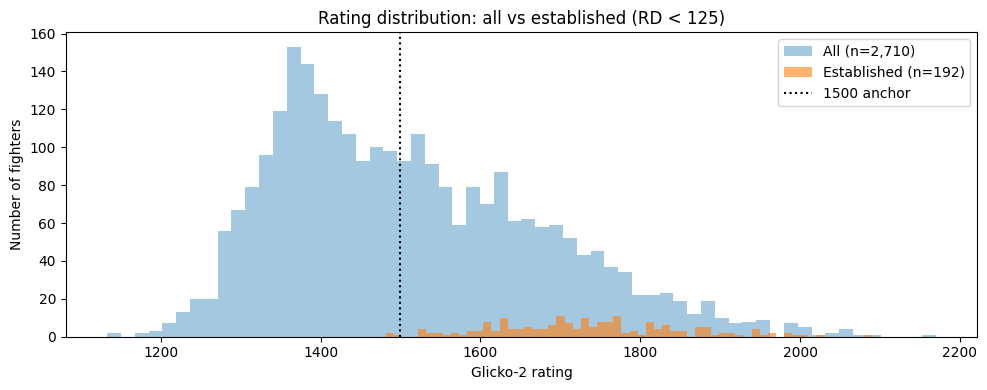


Full population summary:
count    2710.0
mean     1511.5
std       165.7
min      1133.1
25%      1378.8
50%      1484.1
75%      1623.6
max      2169.8

Established only (n=192):
count     192.0
mean     1736.4
std       116.9
min      1481.6
25%      1650.1
50%      1731.3
75%      1815.0
max      2091.8

Established fighters per Section 4.4 band:
  top (1800-2100)     :   53
  mid (1500-1700)     :   70
  bottom (1300-1400)  :    0


In [ ]:
# BLOCK 33: Population shape

# Reads the most recent glicko_current_continuous.parquet and check:
#   Shape vs the 1500 anchor
#   Established subset shape (RD < 125)
#   Count of established fighters

df_current = pd.read_parquet(OUTPUT_DIR / 'glicko_current_continuous.parquet')
established = df_current[df_current['RD'] < 125]

# Histogram
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_current['RATING'], bins=60, alpha=0.4,
        label=f'All (n={len(df_current):,})')
ax.hist(established['RATING'], bins=60, alpha=0.6,
        label=f'Established (n={len(established):,})')
ax.axvline(1500, color='black', linestyle=':', label='1500 anchor')
ax.set_xlabel('Glicko-2 rating')
ax.set_ylabel('Number of fighters')
ax.set_title('Rating distribution: all vs established (RD < 125)')
ax.legend()
plt.tight_layout()
plt.show()

# Summary statistics
print("\nFull population summary:")
print(df_current['RATING'].describe().round(1).to_string())

print(f"\nEstablished only (n={len(established):,}):")
print(established['RATING'].describe().round(1).to_string())

# Established only counts
print("\nEstablished fighters per Section 4.4 band:")
for label, (lo, hi) in [
    ('top (1800-2100)',    (1800, 2100)),
    ('mid (1500-1700)',    (1500, 1700)),
    ('bottom (1300-1400)', (1300, 1400)),
]:
    n = int(established['RATING'].between(lo, hi).sum())
    print(f"  {label:20s}: {n:4d}")

## Conclusion

The Glicko-2 rating system is implemented directly from Glickman (2022) and reproduces the paper's worked example within tolerance before any extension. A continuous-S dominance modifier, calibrated through the anchors in dominance_anchors.yaml, replaces the binary match score for 99% of bouts, so that the margin and manner of victory inform the rating rather than the result alone. Rating deviation classifies each fighter's reliability into Established, Provisional, and Unreliable tiers, and an inactivity decay widens RD for fighters who have not competed recently. Division change was tested for a systematic rating effect and found to have none, so it is treated as fully portable.

The outputs (current ratings, the per-bout rating history, and the calibrated anchor file) form the competitive axis and feed the evaluation and booking notebooks downstream.